# LendingClub Credit Risk — LightGBM Challenger vs. WOE Scorecard

A challenger-model exercise against the final 22-feature WOE/logistic-regression
scorecard in `scorecard.ipynb` (the **champion**). The question a bank's model
committee would ask: *does a gradient-boosted model earn its extra complexity —
and can it be made explainable enough to actually deploy?*

1. **Same inputs, same rules.** Identical 22 features, identical out-of-time design
   (train 2007–2015, test 2016, walk-forward to 2017/2018), Individual applications
   only, no LendingClub `grade`/`sub_grade`/`int_rate` as model inputs.
2. **Monotonic constraints** so every feature moves risk in the direction credit
   logic says it should — the property that makes a tree model defensible to model
   risk and regulators.
3. **Compare** on discrimination (Gini/KS) *and* on dollars at matched approval
   rates, plus a swap-set analysis of exactly which applicants change decision.
4. **Explain** with SHAP, and generate **adverse-action reason codes** for declined
   applicants.
5. **Monitor** with PSI (population stability) on the score and key inputs.

Hyperparameters are tuned on a 2015 validation year only — 2016+ is never touched
until final evaluation.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

Reproduced from `scorecard.ipynb` Sections 1–2 so this notebook runs standalone:
same columns, same Individual-only filter, same resolved-loan definition, same
rolling FICO percentile.

In [2]:
usecols = [
    "loan_amnt", "funded_amnt", "total_pymnt", "term", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "application_type", "acc_open_past_24mths", "bc_open_to_buy",
    "mths_since_recent_bc", "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl", "num_actv_rev_tl", "num_rev_tl_bal_gt_0",
    "num_tl_op_past_12m", "tot_hi_cred_lim", "total_bc_limit",
    "percent_bc_gt_75", "grade", "sub_grade", "int_rate",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 39)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

df = df[df["application_type"] == "Individual"].copy()

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)
resolved["net_profit"] = resolved["total_pymnt"] - resolved["funded_amnt"]
resolved["realized_return"] = resolved["net_profit"] / resolved["funded_amnt"]

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")

Train (issued < 2016): 826,205 loans, default rate 18.42%
Test  (issued 2016)  : 287,819 loans, default rate 23.26%


In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

resolved["fico_percentile"] = df.loc[resolved.index, "fico_percentile"]

## 2. Rebuild the champion scorecard

The WOE binning, logistic regression and points scaling from `scorecard.ipynb`
(Sections 3–6 and the walk-forward refit function from Section 12), reproduced so
the champion can be refit on any training window. Consistency check: 2016 test
Gini must come out at 0.3867, matching the scorecard notebook.

In [5]:
NUMERIC_FEATURES = [
    "loan_to_income", "fico_percentile", "acc_open_past_24mths", "dti",
    "num_tl_op_past_12m", "bc_open_to_buy", "mo_sin_rcnt_tl", "total_bc_limit",
    "tot_hi_cred_lim", "mths_since_recent_inq", "loan_amnt",
    "mo_sin_rcnt_rev_tl_op", "percent_bc_gt_75", "num_actv_rev_tl",
    "num_rev_tl_bal_gt_0", "annual_inc", "mths_since_recent_bc", "mort_acc",
    "revol_util",
]
CATEGORICAL_FEATURES = ["term_months", "verification_status", "home_ownership"]
SELECTED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


BASE_SCORE, BASE_ODDS, PDO = 600, 50, 20
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

In [6]:
def fit_scorecard_on_window(train_window):
    """Refit WOE bins + logistic regression on an arbitrary training window,
    using the already-validated 22-feature set. Returns a scoring function."""
    bin_edges_w, cat_groups_w, woe_tables_w = {}, {}, {}

    for feat in NUMERIC_FEATURES:
        edges = fit_numeric_bins(train_window[feat])
        bin_edges_w[feat] = edges
        binned = apply_numeric_bins(train_window[feat], edges)
        woe_tables_w[feat] = compute_woe_table(binned, train_window["is_default"])

    for feat in CATEGORICAL_FEATURES:
        keep = fit_categorical_groups(train_window[feat])
        cat_groups_w[feat] = keep
        binned = apply_categorical_groups(train_window[feat], keep)
        woe_tables_w[feat] = compute_woe_table(binned, train_window["is_default"])

    def transform_w(data):
        out = pd.DataFrame(index=data.index)
        for feat in SELECTED_FEATURES:
            if feat in NUMERIC_FEATURES:
                binned = apply_numeric_bins(data[feat], bin_edges_w[feat])
            else:
                binned = apply_categorical_groups(data[feat], cat_groups_w[feat])
            out[feat] = binned.map(woe_tables_w[feat]["woe"]).fillna(0.0)
        return out

    X_tr = transform_w(train_window)
    y_tr = train_window["is_default"].values
    model_w = LogisticRegression(solver="lbfgs")
    model_w.fit(X_tr, y_tr)

    def score_w(data):
        Xw = transform_w(data)
        log_odds_bad = model_w.intercept_[0] + Xw.values @ model_w.coef_[0]
        return offset - factor * log_odds_bad

    return model_w, score_w, transform_w

In [7]:
def split_window(test_year):
    train_w = resolved[resolved["issue_d"] < f"{test_year}-01-01"].copy()
    test_w = resolved[(resolved["issue_d"] >= f"{test_year}-01-01")
                      & (resolved["issue_d"] < f"{test_year + 1}-01-01")].copy()
    return train_w, test_w


train, test = split_window(2016)
champion_model, champion_score, champion_transform = fit_scorecard_on_window(train)
test["score_champion"] = champion_score(test)

champion_gini = 2 * roc_auc_score(test["is_default"], -test["score_champion"]) - 1
print(f"Champion 2016 test Gini: {champion_gini:.4f} (scorecard.ipynb: 0.3867)")
assert abs(champion_gini - 0.3867) < 0.001

coefs = pd.Series(champion_model.coef_[0], index=SELECTED_FEATURES)
print("Champion coefficients with counter-intuitive sign (positive = WOE effect reversed):",
      list(coefs[coefs > 0].index))

Champion 2016 test Gini: 0.3867 (scorecard.ipynb: 0.3867)
Champion coefficients with counter-intuitive sign (positive = WOE effect reversed): ['loan_amnt', 'mo_sin_rcnt_rev_tl_op', 'percent_bc_gt_75']


## 3. Monotonic constraint design

Each constraint is set from credit logic first, then checked against the data:
the Spearman correlation between the raw feature and default on the training
window must agree in sign. `verification_status` and `home_ownership` are
unordered categoricals, so they are left unconstrained.

Worth noting: the champion itself has three coefficients with a reversed sign
(printed above) — correlated features pulling against each other. That is
exactly the kind of counter-intuitive behaviour a monotonic constraint rules out
by construction.

In [8]:
INCREASES_RISK = [  # higher value -> higher default risk
    "loan_to_income", "dti", "revol_util", "percent_bc_gt_75", "loan_amnt",
    "acc_open_past_24mths", "num_tl_op_past_12m", "num_actv_rev_tl",
    "num_rev_tl_bal_gt_0", "term_months",
]
DECREASES_RISK = [  # higher value -> lower default risk
    "fico_percentile", "annual_inc", "bc_open_to_buy", "total_bc_limit",
    "tot_hi_cred_lim", "mort_acc", "mo_sin_rcnt_tl", "mo_sin_rcnt_rev_tl_op",
    "mths_since_recent_inq", "mths_since_recent_bc",
]
monotone = [1 if f in INCREASES_RISK else -1 if f in DECREASES_RISK else 0 for f in SELECTED_FEATURES]

check_rows = []
for feat, direction in zip(SELECTED_FEATURES, monotone):
    if direction == 0:
        continue
    valid = train[[feat, "is_default"]].dropna()
    rho = spearmanr(valid[feat], valid["is_default"]).statistic
    check_rows.append({"feature": feat, "constraint": "+1 (up)" if direction > 0 else "-1 (down)",
                       "spearman_vs_default": round(rho, 3), "agrees": np.sign(rho) == direction})
constraint_check = pd.DataFrame(check_rows)
assert constraint_check["agrees"].all(), "A constraint contradicts the training data."
print("All 20 constraints agree with the training data.")
constraint_check

All 20 constraints agree with the training data.


,feature,constraint,spearman_vs_default,agrees
0,loan_to_income,+1 (up),0.136,True
1,fico_percentile,-1 (down),-0.118,True
2,acc_open_past_24mths,+1 (up),0.112,True
3,dti,+1 (up),0.105,True
4,num_tl_op_past_12m,+1 (up),0.097,True
5,bc_open_to_buy,-1 (down),-0.086,True
6,mo_sin_rcnt_tl,-1 (down),-0.076,True
7,total_bc_limit,-1 (down),-0.071,True
8,tot_hi_cred_lim,-1 (down),-0.066,True
9,mths_since_recent_inq,-1 (down),-0.059,True


## 4. Hyperparameter tuning on a 2015 validation year

Train on 2007–2014, early-stop on 2015. The 2016 test year stays untouched. The
winning setting per model (by validation Gini) is then refit on the full
2007–2015 window with the early-stopped number of trees.

In [9]:
CATEGORY_LEVELS = {c: sorted(resolved[c].dropna().unique()) for c in ["verification_status", "home_ownership"]}


def to_lgb_frame(data):
    X = data[SELECTED_FEATURES].copy()
    for col, levels in CATEGORY_LEVELS.items():
        X[col] = pd.Categorical(X[col], categories=levels)
    return X


BASE_PARAMS = dict(objective="binary", learning_rate=0.05, feature_fraction=0.8,
                   bagging_fraction=0.8, bagging_freq=1, lambda_l2=10.0,
                   verbose=-1, seed=0, num_threads=8)
MONOTONE_PARAMS = dict(monotone_constraints=monotone, monotone_constraints_method="advanced")

tune_train = resolved[resolved["issue_d"] < "2015-01-01"]
tune_valid = resolved[(resolved["issue_d"] >= "2015-01-01") & (resolved["issue_d"] < "2016-01-01")]
dtrain = lgb.Dataset(to_lgb_frame(tune_train), tune_train["is_default"])
dvalid = lgb.Dataset(to_lgb_frame(tune_valid), tune_valid["is_default"], reference=dtrain)

tuning_rows = []
for variant, extra in [("unconstrained", {}), ("monotonic", MONOTONE_PARAMS)]:
    for num_leaves in [15, 31, 63]:
        for min_child_samples in [200, 1000]:
            params = dict(BASE_PARAMS, num_leaves=num_leaves, min_child_samples=min_child_samples, **extra)
            booster = lgb.train(params, dtrain, num_boost_round=2000, valid_sets=[dvalid],
                                callbacks=[lgb.early_stopping(100, verbose=False)])
            valid_auc = roc_auc_score(tune_valid["is_default"],
                                      booster.predict(to_lgb_frame(tune_valid), num_iteration=booster.best_iteration))
            tuning_rows.append({"variant": variant, "num_leaves": num_leaves,
                                "min_child_samples": min_child_samples,
                                "n_trees": booster.best_iteration, "valid_gini_2015": 2 * valid_auc - 1})

tuning_df = pd.DataFrame(tuning_rows)
best_settings = tuning_df.loc[tuning_df.groupby("variant")["valid_gini_2015"].idxmax()].set_index("variant")
print(best_settings)
tuning_df.round(4)

               num_leaves  min_child_samples  n_trees  valid_gini_2015
variant                                                               
monotonic              63               1000      365         0.450161
unconstrained          15               1000      913         0.456685


,variant,num_leaves,min_child_samples,n_trees,valid_gini_2015
0,unconstrained,15,200,913,0.4565
1,unconstrained,15,1000,913,0.4567
2,unconstrained,31,200,538,0.4560
3,unconstrained,31,1000,557,0.4561
4,unconstrained,63,200,263,0.4557
5,unconstrained,63,1000,284,0.4559
6,monotonic,15,200,432,0.4491
7,monotonic,15,1000,520,0.4494
8,monotonic,31,200,374,0.4496
9,monotonic,31,1000,366,0.4496


In [10]:
def params_for(variant):
    row = best_settings.loc[variant]
    params = dict(BASE_PARAMS, num_leaves=int(row["num_leaves"]), min_child_samples=int(row["min_child_samples"]))
    if variant == "monotonic":
        params.update(MONOTONE_PARAMS)
    return params, int(row["n_trees"])


def fit_challenger(train_window, variant):
    params, n_trees = params_for(variant)
    return lgb.train(params, lgb.Dataset(to_lgb_frame(train_window), train_window["is_default"]), n_trees)


def pd_to_score(pd_bad):
    """Map a probability of default onto the champion's points scale
    (600 points at 50:1 good:bad odds, 20 points to double the odds)."""
    return offset - factor * np.log(pd_bad / (1 - pd_bad))


MODELS = ["champion", "lgbm_unconstrained", "lgbm_monotonic"]
LABELS = {"champion": "WOE scorecard (champion)",
          "lgbm_unconstrained": "LightGBM, unconstrained",
          "lgbm_monotonic": "LightGBM, monotonic"}

challenger_unc = fit_challenger(train, "unconstrained")
challenger_mono = fit_challenger(train, "monotonic")
test["score_lgbm_unconstrained"] = pd_to_score(challenger_unc.predict(to_lgb_frame(test)))
test["score_lgbm_monotonic"] = pd_to_score(challenger_mono.predict(to_lgb_frame(test)))

## 5. Out-of-time comparison on 2016

Same benchmark as `scorecard.ipynb` Section 7: LendingClub's own grade,
sub-grade and interest rate are shown for reference only (never model inputs).

In [11]:
grade_order = {g: i + 1 for i, g in enumerate("ABCDEFG")}
sub_grade_order = {f"{g}{n}": i + 1 for i, (g, n) in enumerate((g, n) for g in "ABCDEFG" for n in range(1, 6))}
benchmarks = {
    "LC grade": test["grade"].map(grade_order),
    "LC sub_grade": test["sub_grade"].map(sub_grade_order),
    "LC int_rate": test["int_rate"],
}
for m in MODELS:
    benchmarks[LABELS[m]] = -test[f"score_{m}"]  # higher risk = higher value

y_test = test["is_default"].values
perf_rows = []
for label, risk in benchmarks.items():
    auc = roc_auc_score(y_test, risk)
    perf_rows.append({"model": label, "AUC": auc, "Gini": 2 * auc - 1, "KS": ks_statistic(y_test, risk.values)})
oot_perf = pd.DataFrame(perf_rows).set_index("model")
oot_perf.round(4)

,AUC,Gini,KS
model,,,
LC grade,0.6818,0.3635,0.2726
LC sub_grade,0.6912,0.3824,0.2761
LC int_rate,0.6912,0.3823,0.2776
WOE scorecard (champion),0.6934,0.3867,0.2771
"LightGBM, unconstrained",0.7071,0.4142,0.2969
"LightGBM, monotonic",0.7032,0.4064,0.2901


## 6. Walk-forward: 2016, 2017, 2018

For each test year Y, the champion and both challengers are refit on everything
issued before Y (hyperparameters fixed from Section 4) and scored blind on Y.

Business comparison is at **matched approval rates**: each model approves the
same share of applicants, so any difference in bad rate or realized profit is
purely down to *which* applicants each model picks. Profit is real historical
cash flow (`total_pymnt - funded_amnt`), as in the scorecard notebook.

In [12]:
APPROVAL_RATES = [0.5, 0.7, 0.9]

wf_rows, wf_scores = [], {}
for test_year in [2016, 2017, 2018]:
    train_w, test_w = split_window(test_year)
    _, score_w, _ = fit_scorecard_on_window(train_w)
    test_w["score_champion"] = score_w(test_w)
    X_test_w = to_lgb_frame(test_w)
    test_w["score_lgbm_unconstrained"] = pd_to_score(fit_challenger(train_w, "unconstrained").predict(X_test_w))
    test_w["score_lgbm_monotonic"] = pd_to_score(fit_challenger(train_w, "monotonic").predict(X_test_w))
    wf_scores[test_year] = test_w

    for m in MODELS:
        s = test_w[f"score_{m}"]
        auc = roc_auc_score(test_w["is_default"], -s)
        row = {"test_year": test_year, "model": LABELS[m], "gini": 2 * auc - 1,
               "ks": ks_statistic(test_w["is_default"].values, -s.values)}
        for ar in APPROVAL_RATES:
            approved = test_w[s >= s.quantile(1 - ar)]
            row[f"bad_rate@{ar:.0%}"] = approved["is_default"].mean()
            row[f"profit_$M@{ar:.0%}"] = approved["net_profit"].sum() / 1e6
        wf_rows.append(row)

walk_forward_df = pd.DataFrame(wf_rows)
walk_forward_df.round(4)

,test_year,model,gini,ks,bad_rate@50%,profit_$M@50%,bad_rate@70%,profit_$M@70%,bad_rate@90%,profit_$M@90%
0,2016,WOE scorecard (champion),0.3867,0.2771,0.1352,64.7917,0.1669,59.8991,0.2038,15.1565
1,2016,"LightGBM, unconstrained",0.4142,0.2969,0.1286,73.3947,0.1619,70.8110,0.2019,22.1130
2,2016,"LightGBM, monotonic",0.4064,0.2901,0.1310,69.5200,0.1632,66.1982,0.2020,19.5975
3,2017,WOE scorecard (champion),0.3694,0.2660,0.1349,-21.3627,0.1674,-55.6952,0.2028,-120.4159
4,2017,"LightGBM, unconstrained",0.4088,0.2954,0.1251,-10.1667,0.1601,-41.6531,0.1998,-111.1939
5,2017,"LightGBM, monotonic",0.3997,0.2867,0.1278,-12.0664,0.1622,-44.2858,0.2007,-112.9314
6,2018,WOE scorecard (champion),0.3572,0.2586,0.0858,-14.0153,0.1091,-29.3253,0.1334,-54.1083
7,2018,"LightGBM, unconstrained",0.4243,0.3058,0.0748,-7.7892,0.0993,-19.7180,0.1287,-46.3562
8,2018,"LightGBM, monotonic",0.4084,0.2929,0.0775,-9.3574,0.1014,-21.6125,0.1293,-47.8525


In [13]:
gini_pivot = walk_forward_df.pivot(index="test_year", columns="model", values="gini")[[LABELS[m] for m in MODELS]]
profit_pivot = walk_forward_df.pivot(index="test_year", columns="model", values="profit_$M@50%")[[LABELS[m] for m in MODELS]]

uplift = pd.DataFrame({
    "Gini uplift (monotonic - champion)": gini_pivot[LABELS["lgbm_monotonic"]] - gini_pivot[LABELS["champion"]],
    "Profit uplift @50% approval ($M)": profit_pivot[LABELS["lgbm_monotonic"]] - profit_pivot[LABELS["champion"]],
    "Cost of constraints (Gini, unconstrained - monotonic)":
        gini_pivot[LABELS["lgbm_unconstrained"]] - gini_pivot[LABELS["lgbm_monotonic"]],
})
uplift.round(4)

,Gini uplift (monotonic - champion),Profit uplift @50% approval ($M),"Cost of constraints (Gini, unconstrained - monotonic)"
test_year,,,
2016,0.0196,4.7284,0.0078
2017,0.0302,9.2963,0.0091
2018,0.0511,4.6579,0.0160


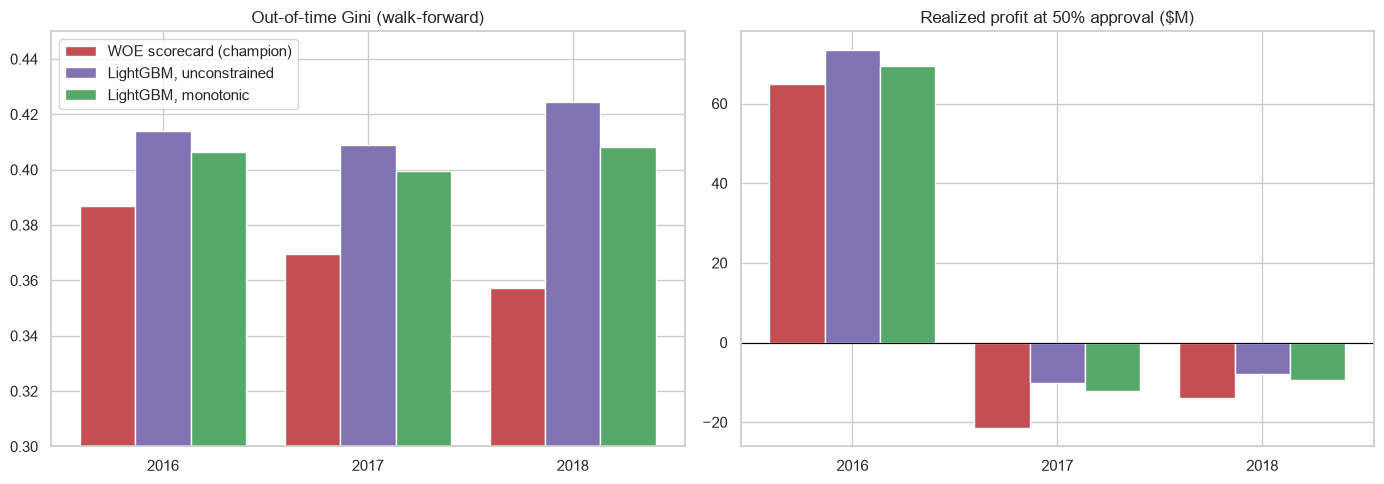

In [14]:
colors = {LABELS["champion"]: "#C44E52", LABELS["lgbm_unconstrained"]: "#8172B3", LABELS["lgbm_monotonic"]: "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(3)
width = 0.27
for k, label in enumerate(gini_pivot.columns):
    axes[0].bar(x + (k - 1) * width, gini_pivot[label], width, label=label, color=colors[label])
    axes[1].bar(x + (k - 1) * width, profit_pivot[label], width, label=label, color=colors[label])
for ax, title in zip(axes, ["Out-of-time Gini (walk-forward)", "Realized profit at 50% approval ($M)"]):
    ax.set_xticks(x)
    ax.set_xticklabels(gini_pivot.index)
    ax.set_title(title)
axes[0].set_ylim(0.3, 0.45)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

## 7. Swap-set analysis (2016, 50% approval rate)

The standard way a credit committee reviews a new model: at the same approval
rate, who does the challenger **swap in** (approve, champion declined) and **swap
out** (decline, champion approved)? A better model swaps in applicants who
perform better than the ones it swaps out.

In [15]:
AR = 0.5
approve_champ = test["score_champion"] >= test["score_champion"].quantile(1 - AR)
approve_chall = test["score_lgbm_monotonic"] >= test["score_lgbm_monotonic"].quantile(1 - AR)

segments = {
    "Approved by both": approve_champ & approve_chall,
    "Swap-in (challenger only)": ~approve_champ & approve_chall,
    "Swap-out (champion only)": approve_champ & ~approve_chall,
    "Declined by both": ~approve_champ & ~approve_chall,
}
swap_rows = []
for name, mask in segments.items():
    seg = test[mask]
    swap_rows.append({"segment": name, "loans": len(seg), "share": len(seg) / len(test),
                      "bad_rate": seg["is_default"].mean(), "profit_$M": seg["net_profit"].sum() / 1e6,
                      "avg_profit_per_loan": seg["net_profit"].mean()})
swap_df = pd.DataFrame(swap_rows).set_index("segment")
swap_df.round(4)

,loans,share,bad_rate,profit_$M,avg_profit_per_loan
segment,,,,,
Approved by both,130743,0.4543,0.1250,66.4765,508.4517
Swap-in (challenger only),13167,0.0457,0.1907,3.0435,231.1494
Swap-out (champion only),13167,0.0457,0.2366,-1.6848,-127.9589
Declined by both,130742,0.4543,0.3441,-139.3191,-1065.6030


## 8. Explainability: SHAP on the monotonic challenger

LightGBM's native TreeSHAP (`pred_contrib=True`) decomposes every prediction
into per-feature contributions in log-odds space, summing exactly to the model
output. Computed on a 20,000-loan sample of the 2016 test year.

In [16]:
shap_sample = test.sample(20_000, random_state=0)
X_shap = to_lgb_frame(shap_sample)
contrib = challenger_mono.predict(X_shap, pred_contrib=True)
shap_values, base_value = contrib[:, :-1], contrib[0, -1]

# additivity check: contributions + base value reproduce the model's log-odds
raw = challenger_mono.predict(X_shap, raw_score=True)
assert np.allclose(shap_values.sum(axis=1) + base_value, raw, atol=1e-6)

display_data = shap_sample[SELECTED_FEATURES].copy()
for col in CATEGORY_LEVELS:
    display_data[col] = display_data[col].astype("category").cat.codes
explanation = shap.Explanation(values=shap_values, base_values=np.full(len(X_shap), base_value),
                               data=display_data.values, feature_names=SELECTED_FEATURES)

importance = pd.Series(np.abs(shap_values).mean(axis=0), index=SELECTED_FEATURES).sort_values(ascending=False)
importance.round(4)

term_months              0.3631
fico_percentile          0.2142
loan_to_income           0.1484
acc_open_past_24mths     0.1363
dti                      0.1350
mths_since_recent_inq    0.1105
total_bc_limit           0.1011
tot_hi_cred_lim          0.0955
mths_since_recent_bc     0.0746
home_ownership           0.0724
bc_open_to_buy           0.0711
num_tl_op_past_12m       0.0697
annual_inc               0.0687
loan_amnt                0.0644
mort_acc                 0.0635
verification_status      0.0438
num_rev_tl_bal_gt_0      0.0375
revol_util               0.0315
mo_sin_rcnt_tl           0.0310
percent_bc_gt_75         0.0228
num_actv_rev_tl          0.0190
mo_sin_rcnt_rev_tl_op    0.0007
dtype: float64

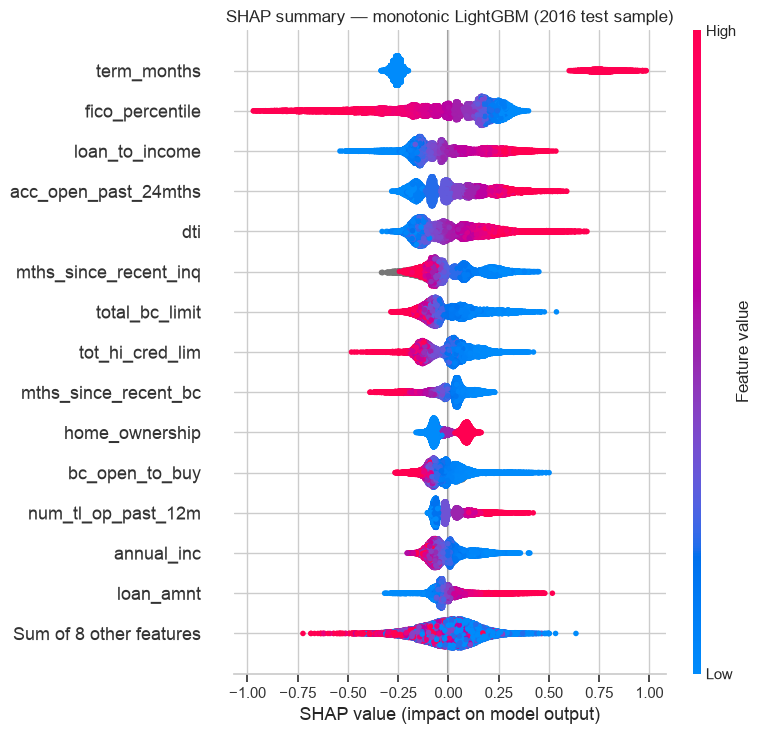

In [17]:
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title("SHAP summary — monotonic LightGBM (2016 test sample)")
plt.tight_layout()
plt.show()

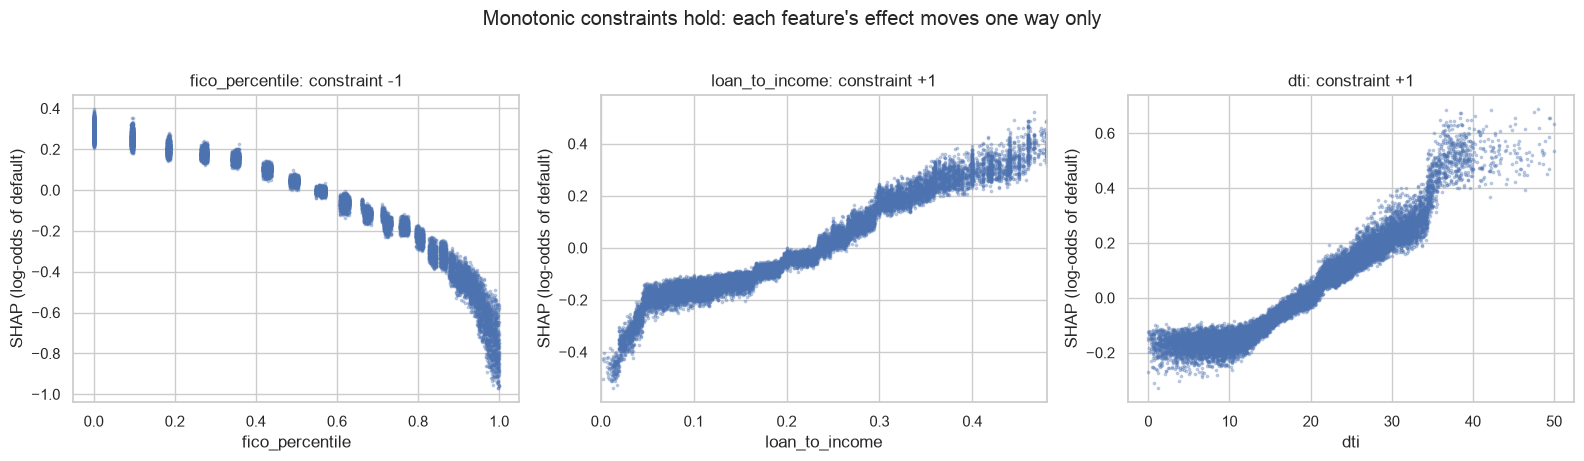

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, ["fico_percentile", "loan_to_income", "dti"]):
    j = SELECTED_FEATURES.index(feat)
    ax.scatter(shap_sample[feat], shap_values[:, j], s=3, alpha=0.3, color="#4C72B0")
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP (log-odds of default)")
    ax.set_title(f"{feat}: constraint {monotone[j]:+d}")
    if feat == "loan_to_income":
        ax.set_xlim(0, shap_sample[feat].quantile(0.99))
plt.suptitle("Monotonic constraints hold: each feature's effect moves one way only", y=1.02)
plt.tight_layout()
plt.show()

## 9. Adverse-action reason codes

When an applicant is declined, lenders must be able to state the principal
reasons (e.g. under the US Equal Credit Opportunity Act). For each declined
applicant, the top three features pushing their risk **up** (largest positive
SHAP) become their reason codes, translated into plain language.

In [19]:
REASON_TEXT = {
    "loan_to_income": "Loan amount is high relative to income",
    "fico_percentile": "Credit score is low relative to recent applicants",
    "acc_open_past_24mths": "Many accounts opened in the last 24 months",
    "dti": "Debt-to-income ratio is high",
    "num_tl_op_past_12m": "Many accounts opened in the last 12 months",
    "bc_open_to_buy": "Little available credit on bankcards",
    "mo_sin_rcnt_tl": "Very recent new account",
    "total_bc_limit": "Low total bankcard credit limit",
    "tot_hi_cred_lim": "Low total credit limit",
    "mths_since_recent_inq": "Recent credit inquiry",
    "loan_amnt": "Requested loan amount is large",
    "mo_sin_rcnt_rev_tl_op": "Very recent new revolving account",
    "percent_bc_gt_75": "High share of bankcards above 75% utilization",
    "num_actv_rev_tl": "Many active revolving accounts",
    "num_rev_tl_bal_gt_0": "Many revolving accounts carrying a balance",
    "annual_inc": "Income is low",
    "mths_since_recent_bc": "Recently opened bankcard",
    "mort_acc": "Few or no mortgage accounts",
    "revol_util": "Revolving credit utilization is high",
    "term_months": "Longer loan term requested",
    "verification_status": "Income verification status",
    "home_ownership": "Housing status",
}
assert set(REASON_TEXT) == set(SELECTED_FEATURES)

cutoff_50 = test["score_lgbm_monotonic"].quantile(1 - AR)
declined = (shap_sample["score_lgbm_monotonic"] < cutoff_50).values
shap_declined = shap_values[declined]
top3 = np.argsort(-shap_declined, axis=1)[:, :3]

reason_codes = pd.DataFrame({
    "score": shap_sample.loc[declined, "score_lgbm_monotonic"].round(1).values,
    **{f"reason_{k + 1}": [REASON_TEXT[SELECTED_FEATURES[j]] for j in top3[:, k]] for k in range(3)},
}, index=shap_sample.index[declined])
print(f"{declined.sum():,} of {len(shap_sample):,} sampled applicants declined at the 50% approval cutoff "
      f"(score < {cutoff_50:.1f})")
reason_codes.head(8)

10,016 of 20,000 sampled applicants declined at the 50% approval cutoff (score < 537.0)


,score,reason_1,reason_2,reason_3
2219104,517.5,Credit score is low relative to recent applicants,Loan amount is high relative to income,Low total bankcard credit limit
1026661,526.9,Low total bankcard credit limit,Low total credit limit,Income is low
2160963,505.0,Longer loan term requested,Low total bankcard credit limit,Credit score is low relative to recent applicants
2010765,524.1,Loan amount is high relative to income,Recent credit inquiry,Credit score is low relative to recent applicants
1009722,495.0,Longer loan term requested,Many accounts opened in the last 24 months,Credit score is low relative to recent applicants
2166374,528.3,Credit score is low relative to recent applicants,Recent credit inquiry,Debt-to-income ratio is high
2245043,533.6,Low total bankcard credit limit,Little available credit on bankcards,Debt-to-income ratio is high
1966497,483.0,Longer loan term requested,Loan amount is high relative to income,Debt-to-income ratio is high


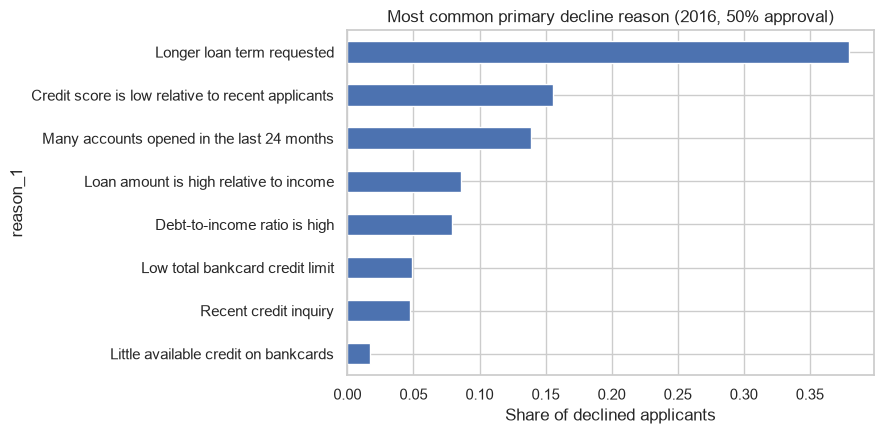

In [20]:
primary_reason_mix = reason_codes["reason_1"].value_counts(normalize=True).head(8)
fig, ax = plt.subplots(figsize=(9, 4.5))
primary_reason_mix.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Share of declined applicants")
ax.set_title("Most common primary decline reason (2016, 50% approval)")
plt.tight_layout()
plt.show()

## 10. Monitoring: Population Stability Index

In production the 2016-deployed model keeps scoring later applicants unchanged
until it is next redeveloped. PSI compares each year's score (and input)
distribution against the development sample (2007–2015), using the development
sample's deciles as bins. Rule of thumb: < 0.10 stable, 0.10–0.25 monitor,
> 0.25 significant shift — investigate or redevelop.

Performance is tracked alongside: the Gini of this *same, un-refit* model on each
later year.

In [21]:
def psi(expected, actual, n_bins=10):
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    edges = np.unique(expected.quantile(np.linspace(0, 1, n_bins + 1)).values)
    edges[0], edges[-1] = -np.inf, np.inf
    e = pd.cut(expected, edges).value_counts(normalize=True, sort=False).values
    a = pd.cut(actual, edges).value_counts(normalize=True, sort=False).values
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


dev_score = pd_to_score(challenger_mono.predict(to_lgb_frame(train)))
monitor_rows = []
for year in [2016, 2017, 2018]:
    _, year_data = split_window(year)
    year_score = pd_to_score(challenger_mono.predict(to_lgb_frame(year_data)))
    row = {"year": year, "loans": len(year_data),
           "score_PSI": psi(dev_score, year_score),
           "gini_static_model": 2 * roc_auc_score(year_data["is_default"], -year_score) - 1}
    for feat in ["fico_percentile", "loan_to_income", "dti", "acc_open_past_24mths", "annual_inc"]:
        row[f"PSI_{feat}"] = psi(train[feat], year_data[feat])
    monitor_rows.append(row)

monitoring_df = pd.DataFrame(monitor_rows).set_index("year")
monitoring_df.round(4)

,loans,score_PSI,gini_static_model,PSI_fico_percentile,PSI_loan_to_income,PSI_dti,PSI_acc_open_past_24mths,PSI_annual_inc
year,,,,,,,,
2016,287819,0.0019,0.4064,0.0485,0.0139,0.0066,0.0299,0.0095
2017,156290,0.0130,0.3905,0.0251,0.0600,0.0019,0.0346,0.0194
2018,49230,0.0179,0.3856,0.0196,0.0880,0.0379,0.0479,0.0254


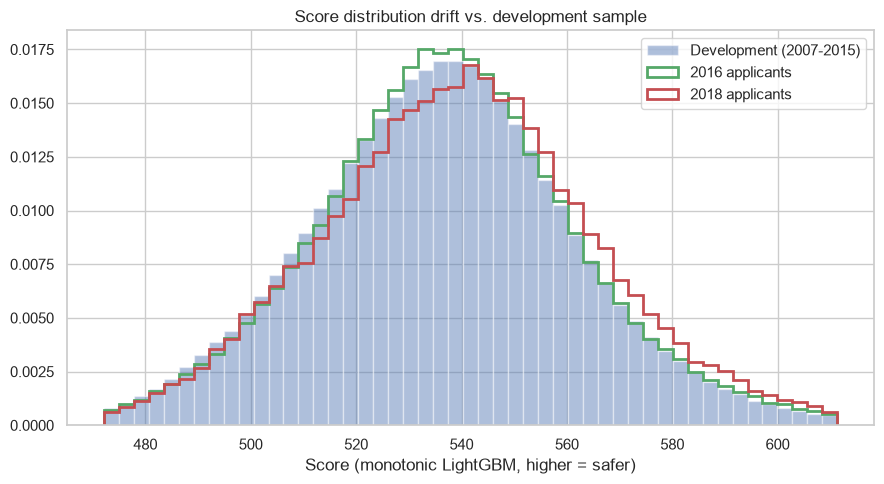

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(np.quantile(dev_score, 0.005), np.quantile(dev_score, 0.995), 50)
ax.hist(dev_score, bins=bins, density=True, alpha=0.45, label="Development (2007-2015)", color="#4C72B0")
for year, color in [(2016, "#55A868"), (2018, "#C44E52")]:
    _, year_data = split_window(year)
    ax.hist(pd_to_score(challenger_mono.predict(to_lgb_frame(year_data))), bins=bins, density=True,
            histtype="step", linewidth=2, label=f"{year} applicants", color=color)
ax.set_xlabel("Score (monotonic LightGBM, higher = safer)")
ax.set_title("Score distribution drift vs. development sample")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Conclusion

**The monotonic LightGBM challenger beats the champion scorecard on every test,
in every year — and the gap widens over time.**

| Test year | Champion Gini | Monotonic LightGBM Gini | Uplift | Profit uplift at 50% approval |
|---|---|---|---|---|
| 2016 | 0.3867 | **0.4064** | +0.020 | **+$4.7M** |
| 2017 | 0.3694 | **0.3997** | +0.030 | **+$9.3M** |
| 2018 | 0.3572 | **0.4084** | +0.051 | **+$4.7M** |

- **Discrimination.** On the 2016 out-of-time test the challenger (Gini 0.406)
  widens the lead over LendingClub's own `int_rate` (0.382) from +0.004 to
  +0.024, on identical inputs to the champion. The champion's Gini decays
  0.387 → 0.357 across the walk-forward; the challenger's holds at 0.40–0.41,
  i.e. it degrades more gracefully as the population shifts.
- **Dollars.** At the same approval rate, the challenger's approved book has a
  lower bad rate in every year (e.g. 13.1% vs 13.5% in 2016 at 50% approval)
  and more realized profit — $4.7M to $9.3M a year from nothing but better
  ranking.
- **Swap set (2016, 50% approval).** Only 4.6% of applicants change decision.
  The 13,167 the challenger swaps in default at 19.1% and made +$3.0M; the
  13,167 it swaps out default at 23.7% and lost -$1.7M. The model is making
  better calls on exactly the marginal applicants where decisions are hardest.
- **Cost of explainability.** Monotonic constraints cost 0.008–0.016 Gini vs.
  the unconstrained model. That is the price of guaranteeing that, for example,
  higher DTI can never *lower* predicted risk — a trade a model-risk committee
  would take every time. The champion itself fails that test on three features
  (reversed coefficient signs from correlated inputs).
- **Explainability in practice.** SHAP contributions sum exactly to the model's
  log-odds, and the dependence plots confirm each constrained feature moves one
  way only. Loan term, FICO percentile, loan-to-income, recent account openings
  and DTI dominate. Every declined applicant gets three plain-language reason
  codes, generated automatically.
- **Monitoring — a lesson in what PSI does *not* catch.** Score PSI stays
  below 0.02 in every year (a completely "stable" population), and no input
  crosses 0.10 — yet the default rate jumped from 18.4% (development) to 23.3%
  in 2016, driven by the post-2016 LendingClub deterioration documented in the
  README. Population stability monitors *who applies*, not *how they perform*:
  production monitoring needs outcome-based tracking (early delinquency,
  vintage curves, calibration of predicted vs. actual PD) alongside PSI.
  `loan_to_income` PSI is trending up (0.014 → 0.088) and would be the first
  input to breach the watch threshold.

**Recommendation:** promote the monotonic LightGBM as the challenger for a
controlled rollout — for example, scoring in parallel and reviewing the swap
set before switching the approve/decline decision — with SHAP reason codes for
adverse-action notices and outcome-based monitoring alongside PSI.

**Caveat:** the champion's 22 features were chosen by a sweep evaluated on 2016
(see README); the challenger reuses them as-is, so any selection advantage sits
with the champion, not the challenger.